[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/03_explainable_alerts.ipynb)

# 03 · Explainable Alerts: Showing Analysts *Why*

**Question:** *can every alert come with a concrete, reviewable reason?*

Fraud teams, auditors, and regulators expect automated decisions to be explainable. For each alert, FinGuard-XAI runs **GNNExplainer**, which learns a mask over the transaction's subgraph that preserves the model's decision. The result is a ranked set of entities and links that drove the alert.

GNNExplainer runs on a *separate model copy* and outside the scoring lock, so explanations never slow down real-time scoring.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


In [2]:
from pathlib import Path
from src.models.train import main as train_main
ART = "artifacts/notebook"
if not Path(ART, "model.pt").exists():   # train a compact model (~1-2 min on CPU)
    train_main(["--n-normal", "10000", "--epochs", "4", "--out", ART,
                "--report", "reports/notebook/RESULTS.md", "--bench-n", "100"])
from src.models.pipeline import FinGuardEngine
engine = FinGuardEngine.load(ART)
print("engine loaded · alert threshold", round(engine.scorer.threshold, 3))

engine loaded · alert threshold 0.479


In [3]:
from src.api.stream_simulator import generate_transactions
from src.models.graph_engine import Transaction
stream = generate_transactions(n_normal=12000, n_rings=12, n_ato=60, seed=123)   # unseen data
split = int(0.7 * len(stream))
for r in stream[:split]:                      # warm the graph with history
    engine.graph.add_transaction(Transaction.from_dict(r))
alert = None
for r in stream[split:]:
    out = engine.score(r)
    if out["is_alert"] and out["explanation"] and r["scenario"] == "ring":
        alert, truth = out, r["scenario"]; break
print(json.dumps({k: alert[k] for k in ("txn_id", "risk_score", "alert_reason", "components", "latency_ms")}, indent=2))
print("ground truth scenario:", truth)

{
  "txn_id": "txn_123_0008963",
  "risk_score": 0.73704,
  "alert_reason": "known-pattern",
  "components": {
    "supervised_prob": 0.97123,
    "anomaly_score": 0.009813,
    "anomaly_percentile": 0.950139
  },
  "latency_ms": {
    "graph_update": 3.404,
    "model_inference": 1.054,
    "scoring_total": 4.459,
    "explanation": 110.12
  }
}
ground truth scenario: ring


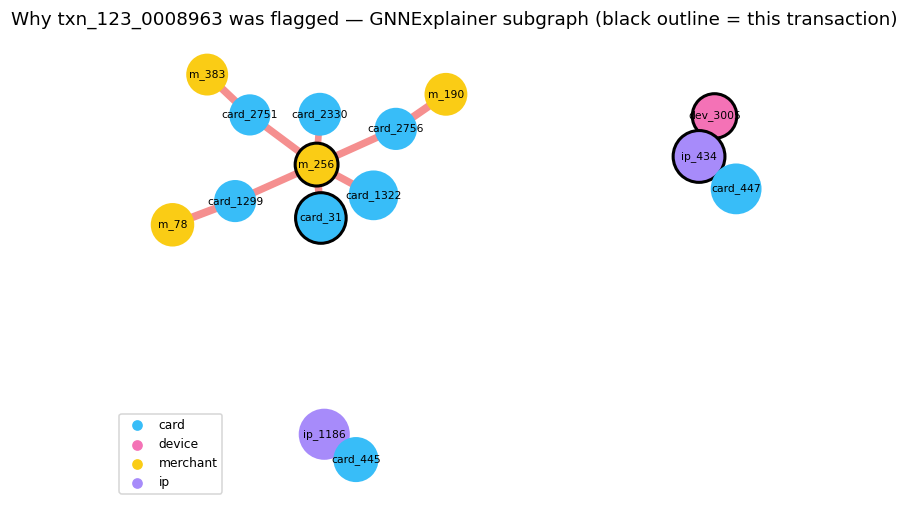

Top relations:
  card-merchant    card:card_1299 — merchant:m_78  weight=0.6844
  card-merchant    card:card_2756 — merchant:m_190  weight=0.6766
  card-ip          ip:ip_1186 — card:card_445  weight=0.6685
  card-merchant    card:card_2751 — merchant:m_383  weight=0.6577
  card-ip          ip:ip_434 — card:card_447  weight=0.6456
  device-ip        device:dev_3005 — ip:ip_434  weight=0.6452


In [4]:
import networkx as nx
exp_ = alert["explanation"]
G = nx.Graph()
for n in exp_["nodes"]: G.add_node(n["id"], **n)
for e in exp_["edges"]: G.add_edge(e["source"], e["target"], weight=e["weight"], relation=e["relation"])
col = {"card": "#38bdf8", "device": "#f472b6", "merchant": "#facc15", "ip": "#a78bfa"}
pos = nx.spring_layout(G, seed=2, weight="weight")
imp = np.array([G.nodes[n]["importance"] for n in G.nodes]); imp = imp / max(imp.max(), 1e-9)
plt.figure(figsize=(8, 5.5))
nx.draw_networkx_edges(G, pos, width=[1 + 6 * G[u][v]["weight"] for u, v in G.edges], edge_color="#ef4444", alpha=.6)
nx.draw_networkx_nodes(G, pos, node_color=[col[G.nodes[n]["type"]] for n in G.nodes], node_size=250 + 900 * imp,
                       edgecolors=["black" if G.nodes[n]["is_transaction_entity"] else "none" for n in G.nodes], linewidths=2)
nx.draw_networkx_labels(G, pos, {n: G.nodes[n]["label"] for n in G.nodes}, font_size=7)
for t, c in col.items(): plt.scatter([], [], color=c, label=t)
plt.legend(loc="lower left", fontsize=8); plt.axis("off")
plt.title(f"Why {alert['txn_id']} was flagged — GNNExplainer subgraph (black outline = this transaction)"); plt.show()
print("Top relations:")
for e in exp_["edges"][:6]:
    print(f"  {e['relation']:<16} {e['source']} — {e['target']}  weight={e['weight']}")

### How an analyst reads this
The highlighted links show *which* shared device, IP address, or merchant connected the flagged card to other activity. That is the evidence an investigator would verify next.

**Limitation (stated deliberately):** explanations describe what the model relied on. They are not proof of fraud or of causation, and a human reviewer makes the final decision.